# BÁO CÁO BỘ DỮ LIỆU THẺ YU-GI-OH!

**Môn học:** Học máy Thống kê  
**Mã lớp:** DS102.R11.CNVN.1  
**Họ tên:** Nguyễn Thanh Hùng Anh  
**MSSV:** 24520003  
**Nguồn dữ liệu:** YGOPRODeck API v7 – Card Information  
**Tệp dữ liệu:** `data/yugioh.csv`  

## 1. Giới thiệu

Trình bày kết quả khảo sát bộ dữ liệu thẻ Yu-Gi-Oh! được thu thập từ YGOPRODeck API và chuyển đổi sang định dạng CSV. Nội dung tập trung vào cấu trúc dữ liệu, chất lượng dữ liệu, thống kê mô tả và trực quan hóa một số thuộc tính.

Để thuận tiện cho việc phân tích bằng các phương pháp thống kê cơ bản, dữ liệu đầu ra được giới hạn ở 19 cột dạng số. Các trường văn bản như tên thẻ, mô tả hiệu ứng và đường dẫn hình ảnh không được đưa vào CSV. Các thuộc tính phân loại được biểu diễn bằng một số cờ nhị phân và cột `card_category`.

`card_category` được quy ước: **0 = Monster, 1 = Spell, 2 = Trap, 3 = Skill, 4 = Other**. Các mã số này chỉ dùng để biểu diễn nhóm thẻ, không thể hiện thứ tự hay mức độ hơn kém giữa các nhóm.

Nguồn dữ liệu: <https://db.ygoprodeck.com/api/v7/cardinfo.php>.


## 2. Công cụ và dữ liệu sử dụng

Dữ liệu được lưu trong tệp `data/yugioh.csv` và được đọc vào DataFrame để thực hiện các bước thống kê.  
Pandas được sử dụng để xử lý bảng dữ liệu, NumPy hỗ trợ thao tác với dữ liệu số và Matplotlib được dùng để tạo biểu đồ.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "data/yugioh.csv"

df = pd.read_csv(DATA_PATH)
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
display(df.head())

Số dòng: 14599
Số cột: 19


,card_id,atk,def,level_rank,linkval,scale,link_marker_count,price_cardmarket_eur,price_tcgplayer_usd,is_extra_deck,is_pendulum,is_fusion,is_ritual,is_synchro,is_xyz,is_link,is_effect,is_normal,card_category
0,149694341,NaN,NaN,NaN,NaN,NaN,0,0.00,0.00,0,0,0,0,0,0,0,0,0,1
1,80181649,NaN,NaN,NaN,NaN,NaN,0,0.16,0.17,0,0,0,0,0,0,0,0,0,1
2,34541863,NaN,NaN,NaN,NaN,NaN,0,0.06,0.21,0,0,0,0,0,0,0,0,0,1
3,64163367,NaN,NaN,NaN,NaN,NaN,0,0.14,0.18,0,0,0,0,0,0,0,0,0,1
4,91231901,NaN,NaN,NaN,NaN,NaN,0,0.05,0.11,0,0,0,0,0,0,0,0,0,1


## 3. Cấu trúc và ý nghĩa các thuộc tính

Mỗi dòng trong CSV tương ứng với một bản ghi thẻ được trả về từ API. Bộ dữ liệu có 19 cột, được chia thành các nhóm sau:

- **Mã định danh:** `card_id` dùng để nhận diện bản ghi thẻ. Đây là mã định danh, không phải đại lượng đo lường.
- **Chỉ số của thẻ:** `atk`, `def`, `level_rank`, `linkval`, `scale` và `link_marker_count`.
- **Giá tham khảo:** `price_cardmarket_eur` (EUR) và `price_tcgplayer_usd` (USD). Hai trường này đến từ các nguồn khác nhau và sử dụng đơn vị tiền tệ khác nhau.
- **Đặc điểm nhị phân:** `is_extra_deck`, `is_pendulum`, `is_fusion`, `is_ritual`, `is_synchro`, `is_xyz`, `is_link`, `is_effect`, `is_normal`. Giá trị 1 biểu thị đặc điểm được nhận diện trong dữ liệu loại thẻ; giá trị 0 biểu thị không nhận diện được đặc điểm đó.
- **Nhóm thẻ:** `card_category` mã hóa nhóm thẻ thành các giá trị từ 0 đến 4 như đã trình bày ở phần giới thiệu.

Các ô trống được giữ nguyên khi API không cung cấp giá trị tương ứng hoặc khi giá trị không thể chuyển đổi sang dạng số. Vì một số thuộc tính chỉ áp dụng cho một số loại thẻ, số lượng giá trị hợp lệ có thể khác nhau giữa các cột.


In [3]:
print("Kiểu dữ liệu các cột:")
display(df.dtypes.value_counts().rename_axis("Kiểu dữ liệu").to_frame("Số cột"))

cot_khong_phai_so = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Cột không phải số:", cot_khong_phai_so if cot_khong_phai_so else "Không có")

if "card_id" in df.columns:
    print("Số card_id khác nhau:", df["card_id"].nunique(dropna=True))
if "card_category" in df.columns:
    print("Các mã card_category có trong dữ liệu:", sorted(df["card_category"].dropna().unique().tolist()))


Kiểu dữ liệu các cột:


,Số cột
Kiểu dữ liệu,
int64,12
float64,7


Cột không phải số: Không có
Số card_id khác nhau: 14599
Các mã card_category có trong dữ liệu: [0, 1, 2, 3, 4]


## 4. Kiểm tra chất lượng dữ liệu

Chất lượng dữ liệu được khảo sát thông qua số lượng giá trị thiếu, số dòng trùng hoàn toàn và số mã `card_id` trùng lặp. Bảng và biểu đồ dưới đây thể hiện kết quả kiểm tra trên tệp CSV.

Giá trị thiếu không nhất thiết là lỗi. Chẳng hạn, một số thuộc tính chiến đấu chỉ áp dụng cho những loại thẻ nhất định nên có thể không xuất hiện ở mọi bản ghi.


Số dòng trùng hoàn toàn: 0
Số card_id bị trùng (không tính bản đầu tiên): 0
Tổng số ô thiếu: 44819
Số cột có dữ liệu thiếu: 5


,So o thieu
scale,14209
linkval,14125
def,5689
level_rank,5581
atk,5215


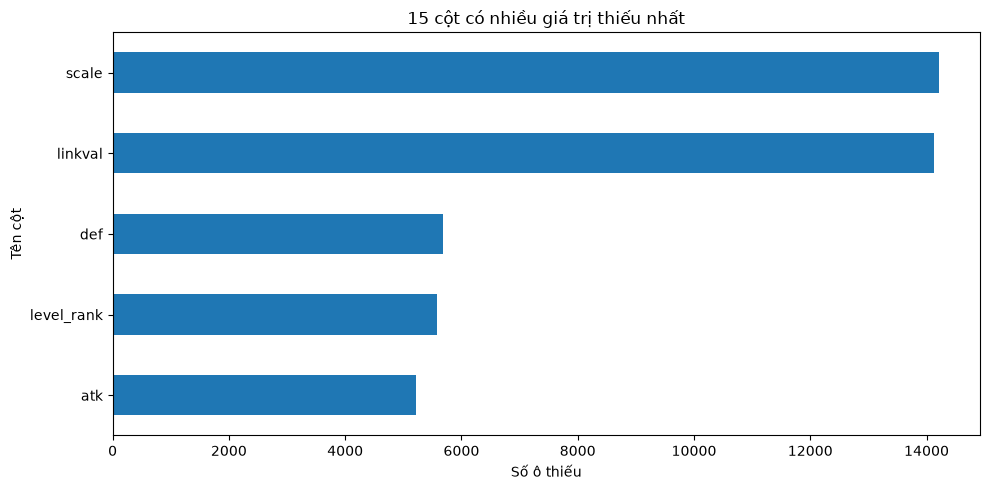

In [4]:
print("Số dòng trùng hoàn toàn:", int(df.duplicated().sum()))
if "card_id" in df.columns:
    print("Số card_id bị trùng (không tính bản đầu tiên):", int(df["card_id"].duplicated().sum()))

thieu = df.isna().sum().sort_values(ascending=False)
thieu_co_gia_tri = thieu[thieu > 0]
print("Tổng số ô thiếu:", int(df.isna().sum().sum()))
print("Số cột có dữ liệu thiếu:", int((df.isna().sum() > 0).sum()))
display(thieu_co_gia_tri.head(20).rename("So o thieu").to_frame())

if len(thieu_co_gia_tri) > 0:
    plt.figure(figsize=(10, 5))
    thieu_co_gia_tri.head(15).sort_values().plot(kind="barh")
    plt.title("15 cột có nhiều giá trị thiếu nhất")
    plt.xlabel("Số ô thiếu")
    plt.ylabel("Tên cột")
    plt.tight_layout()
    plt.show()
else:
    print("Không có ô thiếu trong CSV này.")

## 5. Thống kê mô tả các thuộc tính số

Bảng thống kê trình bày số lượng giá trị hợp lệ, giá trị trung bình, độ lệch chuẩn, giá trị nhỏ nhất, các phân vị và giá trị lớn nhất của những thuộc tính số chính. `card_id` được loại khỏi bảng vì chỉ là mã định danh; `card_category` cũng được loại vì là mã nhóm, không phải biến định lượng liên tục.


In [5]:
cot_chinh = [
    "atk", "def", "level_rank", "linkval", "scale", "link_marker_count",
    "price_cardmarket_eur", "price_tcgplayer_usd"
]
cot_chinh = [cot for cot in cot_chinh if cot in df.columns]
display(df[cot_chinh].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
atk,9384.0,1520.43,963.75,-1.0,800.00,1500.00,2200.00,5000.00
def,8910.0,1287.83,883.35,-1.0,600.00,1200.00,2000.00,5000.00
level_rank,9018.0,4.67,2.50,0.0,3.00,4.00,6.00,13.00
linkval,474.0,2.46,1.00,1.0,2.00,2.00,3.00,6.00
scale,390.0,4.26,3.17,0.0,1.00,4.00,7.00,13.00
link_marker_count,14599.0,0.08,0.47,0.0,0.00,0.00,0.00,6.00
price_cardmarket_eur,14599.0,0.89,10.30,0.0,0.06,0.12,0.26,720.91
price_tcgplayer_usd,14599.0,1.22,18.80,0.0,0.12,0.19,0.33,1800.00


## 6. Phân bố ATK và DEF

Hai biểu đồ histogram thể hiện phân bố của ATK và DEF trong các bản ghi có dữ liệu hợp lệ. Các biểu đồ giúp quan sát khoảng giá trị tập trung, độ phân tán và những giá trị xuất hiện ít hơn. Những bản ghi không có giá trị ở thuộc tính tương ứng không được đưa vào biểu đồ đó.


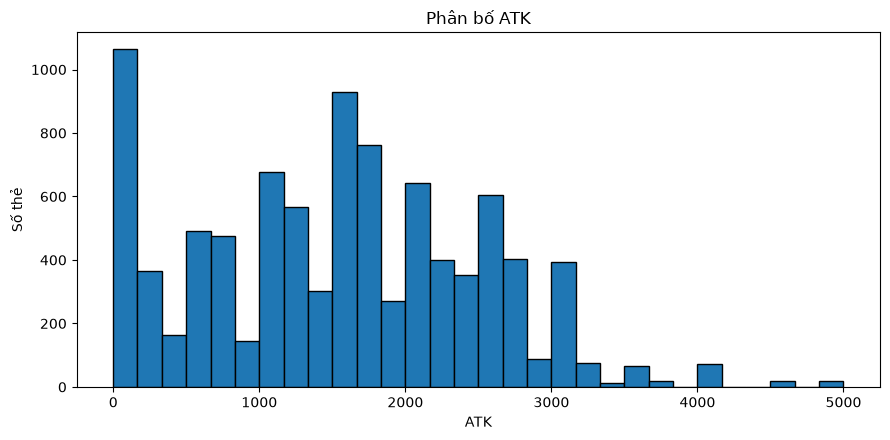

ATK - số giá trị hợp lệ: 9384 | trung vị: 1500.0


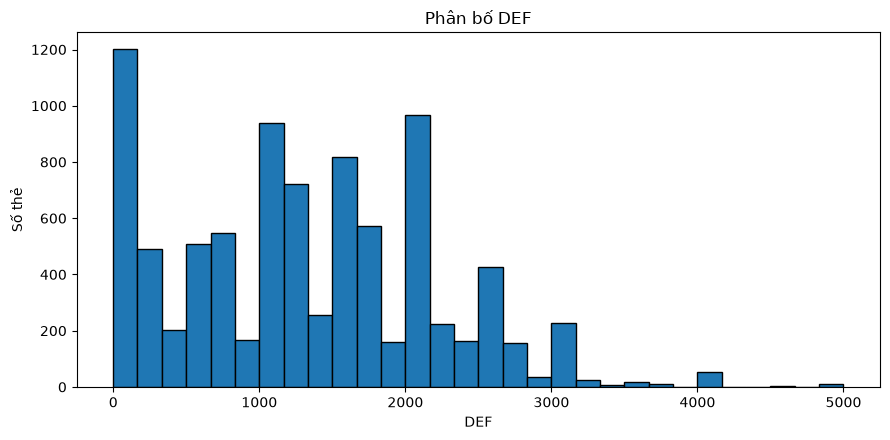

DEF - số giá trị hợp lệ: 8910 | trung vị: 1200.0


In [6]:
for cot in ["atk", "def"]:
    if cot in df.columns:
        gia_tri = df[cot].dropna()
        if len(gia_tri) > 0:
            plt.figure(figsize=(9, 4.5))
            plt.hist(gia_tri, bins=30, edgecolor="black")
            plt.title("Phân bố " + cot.upper())
            plt.xlabel(cot.upper())
            plt.ylabel("Số thẻ")
            plt.tight_layout()
            plt.show()
            print(cot.upper(), "- số giá trị hợp lệ:", len(gia_tri),
                  "| trung vị:", round(gia_tri.median(), 2))

## 7. Tần suất các đặc điểm của thẻ

Biểu đồ so sánh số bản ghi có giá trị bằng 1 ở từng cột đặc điểm. Một thẻ có thể đồng thời mang nhiều đặc điểm, vì vậy các nhóm không loại trừ lẫn nhau và tổng số đếm giữa các cột có thể lớn hơn số bản ghi của bộ dữ liệu.


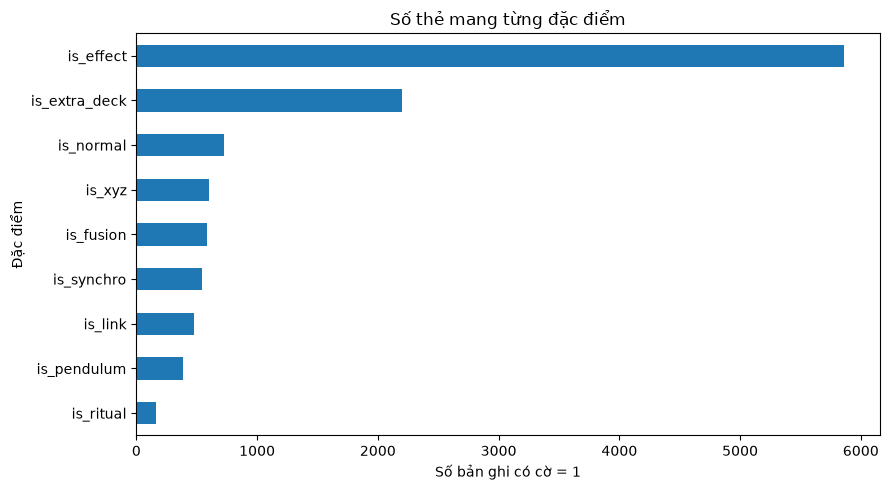

,Số thẻ
is_effect,5862
is_extra_deck,2201
is_normal,722
is_xyz,603
is_fusion,582
is_synchro,542
is_link,474
is_pendulum,386
is_ritual,159


In [7]:
cot_co = [
    "is_extra_deck", "is_pendulum", "is_fusion", "is_ritual",
    "is_synchro", "is_xyz", "is_link", "is_effect", "is_normal"
]
cot_co = [cot for cot in cot_co if cot in df.columns]
if cot_co:
    dem_nhom = df[cot_co].fillna(0).sum().sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    dem_nhom.sort_values().plot(kind="barh")
    plt.title("Số thẻ mang từng đặc điểm")
    plt.xlabel("Số bản ghi có cờ = 1")
    plt.ylabel("Đặc điểm")
    plt.tight_layout()
    plt.show()
    display(dem_nhom.rename("Số thẻ").to_frame())
else:
    print("Không tìm thấy các cột cờ loại thẻ.")


## 8. Phân bố nhóm thẻ chính

Cột `card_category` lưu mã số đại diện cho nhóm thẻ. Trên biểu đồ, các mã số được hiển thị bằng tên nhóm tương ứng để kết quả dễ đọc hơn; dữ liệu trong CSV vẫn giữ nguyên dạng mã số.


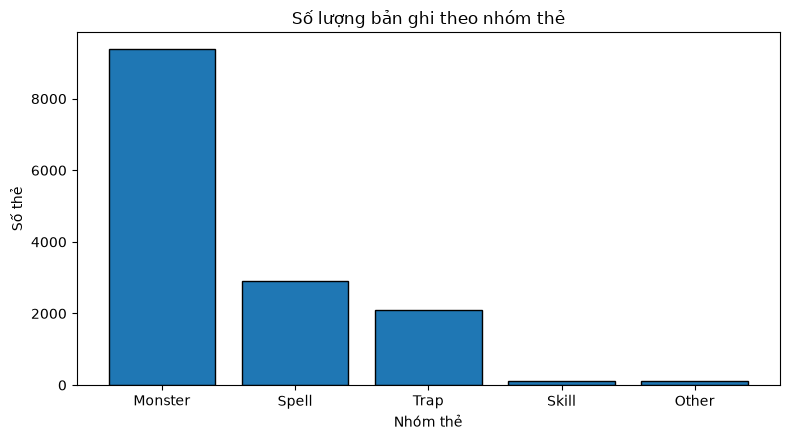

,Số thẻ
card_category,
Monster,9385
Spell,2896
Trap,2088
Skill,124
Other,106


In [8]:
ten_nhom = {
    0: "Monster",
    1: "Spell",
    2: "Trap",
    3: "Skill",
    4: "Other",
}
if "card_category" in df.columns:
    dem_nhom = df["card_category"].value_counts().sort_index()
    ten_hien_thi = [ten_nhom.get(int(ma), f"Other ({ma})") for ma in dem_nhom.index]
    plt.figure(figsize=(8, 4.5))
    plt.bar(ten_hien_thi, dem_nhom.values, edgecolor="black")
    plt.title("Số lượng bản ghi theo nhóm thẻ")
    plt.xlabel("Nhóm thẻ")
    plt.ylabel("Số thẻ")
    plt.tight_layout()
    plt.show()
    bang_nhom = dem_nhom.rename(index=ten_nhom).rename("Số thẻ").to_frame()
    display(bang_nhom)
else:
    print("Không tìm thấy cột card_category.")


## 9. Mối liên hệ giữa ATK và DEF

Biểu đồ phân tán thể hiện ATK và DEF của những bản ghi có đủ cả hai giá trị. Mỗi điểm tương ứng với một bản ghi. Nếu số bản ghi vượt quá 3.000, biểu đồ sử dụng một mẫu cố định gồm tối đa 3.000 bản ghi để tránh hiển thị quá dày.


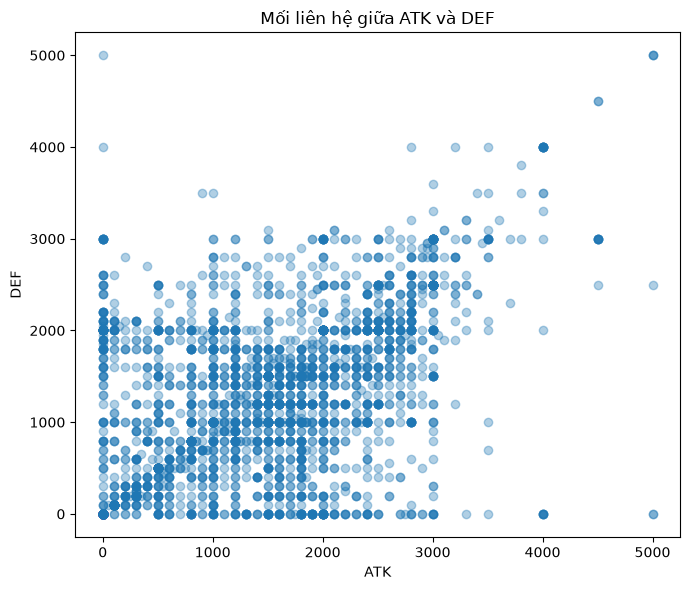

Số điểm được vẽ: 3000


In [9]:
if "atk" in df.columns and "def" in df.columns:
    scatter_data = df[["atk", "def"]].dropna()
    if len(scatter_data) > 3000:
        scatter_data = scatter_data.sample(n=3000, random_state=42)
    if len(scatter_data) > 0:
        plt.figure(figsize=(7, 6))
        plt.scatter(scatter_data["atk"], scatter_data["def"], alpha=0.35)
        plt.title("Mối liên hệ giữa ATK và DEF")
        plt.xlabel("ATK")
        plt.ylabel("DEF")
        plt.tight_layout()
        plt.show()
        print("Số điểm được vẽ:", len(scatter_data))
    else:
        print("Không có dòng nào đồng thời có ATK và DEF.")

## 10. So sánh ATK theo nhóm thẻ

Boxplot được dùng để so sánh trung vị và mức độ phân tán của ATK giữa các nhóm thẻ có đủ dữ liệu. ATK chủ yếu có ý nghĩa đối với quái thú, do đó số lượng quan sát hợp lệ giữa các nhóm có thể chênh lệch đáng kể. Những nhóm có ít hơn 10 giá trị ATK hợp lệ không được đưa vào biểu đồ.


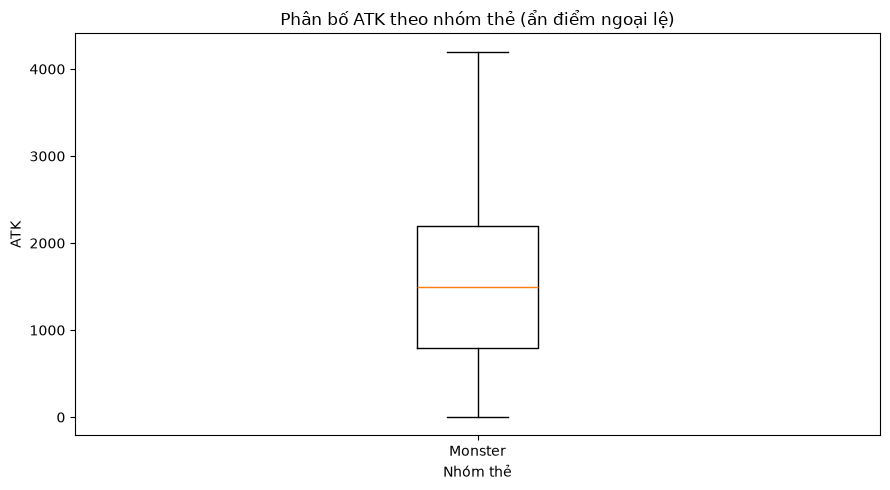

In [13]:
ten_nhom = {
    0: "Monster",
    1: "Spell",
    2: "Trap",
    3: "Skill",
    4: "Other",
}
if "atk" in df.columns and "card_category" in df.columns:
    du_lieu_box = []
    nhan_box = []
    for ma_nhom in sorted(df["card_category"].dropna().unique()):
        nhom = df.loc[(df["card_category"] == ma_nhom) & df["atk"].notna(), "atk"]
        if len(nhom) >= 10:
            du_lieu_box.append(nhom)
            nhan_box.append(ten_nhom.get(int(ma_nhom), f"Other ({ma_nhom})"))

    if du_lieu_box:
        plt.figure(figsize=(9, 5))
        plt.boxplot(du_lieu_box, tick_labels=nhan_box, showfliers=False)
        plt.title("Phân bố ATK theo nhóm thẻ (ẩn điểm ngoại lệ)")
        plt.xlabel("Nhóm thẻ")
        plt.ylabel("ATK")
        plt.tight_layout()
        plt.show()
    else:
        print("Chưa đủ dữ liệu ATK theo nhóm để vẽ boxplot.")


## 11. Tương quan giữa các biến số

Ma trận tương quan Pearson mô tả mức độ liên hệ tuyến tính giữa các thuộc tính số được chọn. `card_id` không được sử dụng vì là mã định danh, còn `card_category` là mã nhóm. Hệ số tương quan nằm trong khoảng từ -1 đến 1; kết quả phản ánh mối liên hệ trong dữ liệu. Số cặp quan sát dùng để tính tương quan có thể khác nhau do giá trị thiếu.


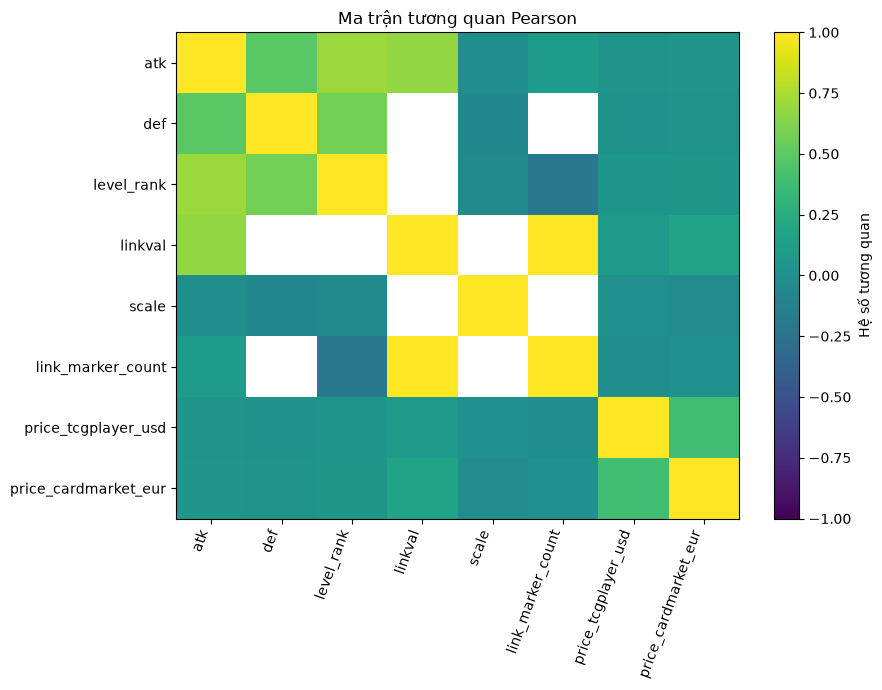

,atk,def,level_rank,linkval,scale,link_marker_count,price_tcgplayer_usd,price_cardmarket_eur
atk,1.00,0.49,0.70,0.68,-0.01,0.10,0.03,0.04
def,0.49,1.00,0.58,NaN,-0.07,NaN,0.02,0.04
level_rank,0.70,0.58,1.00,NaN,-0.05,-0.19,0.05,0.06
linkval,0.68,NaN,NaN,1.00,NaN,1.00,0.07,0.17
scale,-0.01,-0.07,-0.05,NaN,1.00,NaN,0.01,-0.03
link_marker_count,0.10,NaN,-0.19,1.00,NaN,1.00,-0.00,0.01
price_tcgplayer_usd,0.03,0.02,0.05,0.07,0.01,-0.00,1.00,0.38
price_cardmarket_eur,0.04,0.04,0.06,0.17,-0.03,0.01,0.38,1.00


In [14]:
cot_tuong_quan = [
    "atk", "def", "level_rank", "linkval", "scale", "link_marker_count",
    "price_tcgplayer_usd", "price_cardmarket_eur"
]
cot_tuong_quan = [c for c in cot_tuong_quan if c in df.columns]
if len(cot_tuong_quan) >= 2:
    corr = df[cot_tuong_quan].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    image = ax.imshow(corr, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=70, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Ma trận tương quan Pearson")
    fig.colorbar(image, ax=ax, label="Hệ số tương quan")
    plt.tight_layout()
    plt.show()
    display(corr.round(2))
else:
    print("Không đủ cột số để tính tương quan.")


## 12. Phân bố giá tham khảo TCGplayer

Mục này khảo sát riêng cột `price_tcgplayer_usd`. Số lượng giá trị thiếu, giá trị bằng 0 và giá trị dương được thống kê riêng. Histogram được xây dựng từ các giá trị dương để mô tả phân bố giá tham khảo, không gộp các trường hợp thiếu với giá bằng 0.


Giá trị thiếu: 0
Giá bằng 0: 496
Giá dương: 14103


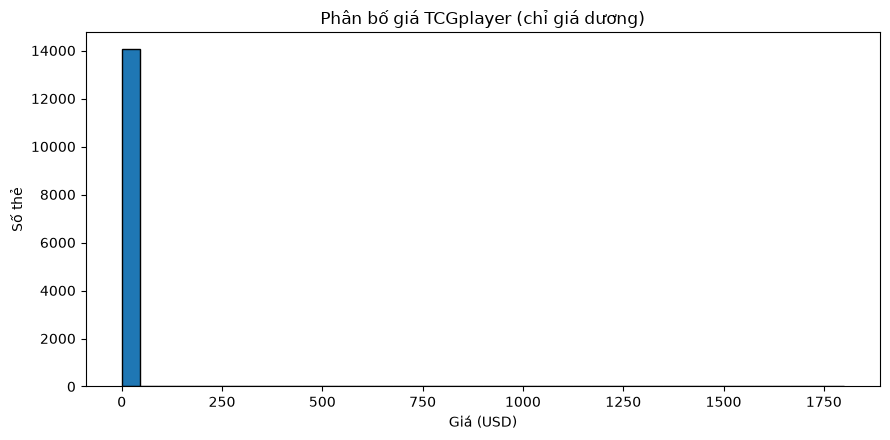

,TCGplayer USD
count,14103.000
mean,1.258
std,19.131
min,0.010
25%,0.130
50%,0.200
75%,0.340
max,1800.000


In [15]:
cot_gia = "price_tcgplayer_usd"
if cot_gia in df.columns:
    gia = df[cot_gia]
    print("Giá trị thiếu:", int(gia.isna().sum()))
    print("Giá bằng 0:", int((gia == 0).sum()))
    gia_duong = gia[gia > 0]
    print("Giá dương:", len(gia_duong))
    if len(gia_duong) > 0:
        plt.figure(figsize=(9, 4.5))
        plt.hist(gia_duong, bins=40, edgecolor="black")
        plt.title("Phân bố giá TCGplayer (chỉ giá dương)")
        plt.xlabel("Giá (USD)")
        plt.ylabel("Số thẻ")
        plt.tight_layout()
        plt.show()
        display(gia_duong.describe().to_frame("TCGplayer USD").round(3))

## 13. Tổng hợp kết quả khảo sát

Các chỉ số dưới đây tổng hợp quy mô bộ dữ liệu, mức độ đầy đủ của một số thuộc tính quan trọng và số lượng nhãn nhóm thẻ. Những con số được tính trực tiếp từ CSV nhằm tóm lược các kết quả đã trình bày ở những mục trước.


In [17]:
so_dong, so_cot = df.shape
so_o_thieu = int(df.isna().sum().sum())
so_dong_trung = int(df.duplicated().sum())
print(f"Bộ dữ liệu có {so_dong:,} dòng và {so_cot:,} cột.")
print(f"Tổng số ô thiếu: {so_o_thieu:,}.")
print(f"Số dòng trùng hoàn toàn: {so_dong_trung:,}.")

if "atk" in df.columns:
    print("Số dòng có ATK:", int(df["atk"].notna().sum()))
    if df["atk"].notna().any():
        print("ATK trung vị:", float(df["atk"].median()))
if "price_tcgplayer_usd" in df.columns:
    print("Số dòng có giá TCGplayer:", int(df["price_tcgplayer_usd"].notna().sum()))
if "card_category" in df.columns:
    print("Số nhãn phân loại khác nhau:", int(df["card_category"].nunique(dropna=True)))

print("\nDiễn giải:")
print("- card_id chỉ là định danh, không nên coi là đặc trưng đầu vào.")
print("- card_category là mã lớp: 0 Monster, 1 Spell, 2 Trap, 3 Skill, 4 Other.")
print("- Các cột giá thuộc nguồn/đơn vị khác nhau.")
print("- Giá trị thiếu ở ATK/DEF/Level/Link/Scale có thể do loại thẻ không sử dụng thuộc tính đó.")
print("- Dataset được giới hạn ở 19 cột số để tránh tạo quá nhiều biến one-hot.")


Bộ dữ liệu có 14,599 dòng và 19 cột.
Tổng số ô thiếu: 44,819.
Số dòng trùng hoàn toàn: 0.
Số dòng có ATK: 9384
ATK trung vị: 1500.0
Số dòng có giá TCGplayer: 14599
Số nhãn phân loại khác nhau: 5

Diễn giải:
- card_id chỉ là định danh, không nên coi là đặc trưng đầu vào.
- card_category là mã lớp: 0 Monster, 1 Spell, 2 Trap, 3 Skill, 4 Other.
- Các cột giá thuộc nguồn/đơn vị khác nhau.
- Giá trị thiếu ở ATK/DEF/Level/Link/Scale có thể do loại thẻ không sử dụng thuộc tính đó.
- Dataset được giới hạn ở 19 cột số để tránh tạo quá nhiều biến one-hot.


## 14. Kết luận

Báo cáo đã khảo sát cấu trúc và một số đặc điểm thống kê của bộ dữ liệu Yu-Gi-Oh! sau khi chuyển đổi sang CSV. Bộ dữ liệu gồm 19 cột số, bao gồm mã định danh, các chỉ số của thẻ, giá tham khảo, cờ nhị phân và mã nhóm thẻ. Các bảng thống kê và biểu đồ cung cấp cái nhìn tổng quan về phân bố thuộc tính, mức độ thiếu dữ liệu và mối liên hệ giữa một số biến.

Trong quá trình đọc kết quả, cần lưu ý rằng `card_id` chỉ có vai trò định danh; các mã trong `card_category` biểu diễn nhóm, không phải thang đo số học; hai cột giá sử dụng đơn vị tiền tệ khác nhau. Ngoài ra, giá trị thiếu ở ATK, DEF, Level/Rank, Link Value hoặc Scale có thể xuất phát từ đặc điểm của từng loại thẻ.

Một hạn chế của bộ dữ liệu là thông tin giá có thể không đầy đủ và có thể thay đổi theo nhà cung cấp hoặc thời điểm thu thập. Vì vậy, các kết quả thống kê trong báo cáo phản ánh dữ liệu tại lần thu thập này, không đại diện cho giá thị trường ở mọi thời điểm.
